# Superstore Sales Analysis - Exploratory Data Analysis (EDA)

**Goal:** understand where Superstore makes and loses money, and which factors (category, region, segment, discount) drive profit.

**Dataset:** cleaned Superstore data (9,977 rows). Each row is one order line (there is no Order ID), so averages below are *per row*, not per order.

**Tools:** Python (pandas, matplotlib). The final business insights are presented in the Power BI dashboard.

In [2]:
# ============================================
# SETUP AND DATA LOADING
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

# Dashboard colour palette
NAVY = "#0B2A5B"
RED = "#C8102E"

def bar_colors(values):
    """Navy for profit, red for loss."""
    return [RED if v < 0 else NAVY for v in values]

# Load cleaned dataset
df = pd.read_excel("../data/Cleaned/Superstore_Cleaned.xlsx")

print("First 5 rows of cleaned dataset:")
display(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()

# Data quality checks
print("\nMissing values per column:")
print(df.isnull().sum())

print(f"\nDuplicate rows: {df.duplicated().sum()}")

First 5 rows of cleaned dataset:


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164



Dataset Shape:
(9977, 13)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9977 entries, 0 to 9976
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9977 non-null   object 
 1   Segment       9977 non-null   object 
 2   Country       9977 non-null   object 
 3   City          9977 non-null   object 
 4   State         9977 non-null   object 
 5   Postal Code   9977 non-null   int64  
 6   Region        9977 non-null   object 
 7   Category      9977 non-null   object 
 8   Sub-Category  9977 non-null   object 
 9   Sales         9977 non-null   float64
 10  Quantity      9977 non-null   int64  
 11  Discount      9977 non-null   float64
 12  Profit        9977 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1013.4+ KB

Missing values per column:
Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     

## 1. Overall Business Performance

In [3]:
# ============================================
# OVERALL BUSINESS PERFORMANCE
# ============================================

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_quantity = df["Quantity"].sum()
average_sales_per_row = df["Sales"].mean()
average_profit_per_row = df["Profit"].mean()
average_discount = df["Discount"].mean()
profit_margin = (total_profit / total_sales) * 100

print("============================================")
print("OVERALL BUSINESS PERFORMANCE")
print("============================================")
print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Quantity Sold: {total_quantity:,}")
print(f"Average Sales per Row: ${average_sales_per_row:,.2f}")
print(f"Average Profit per Row: ${average_profit_per_row:,.2f}")
print(f"Average Discount: {average_discount:.2%}")
print(f"Overall Profit Margin: {profit_margin:.2f}%")

OVERALL BUSINESS PERFORMANCE
Total Sales: $2,296,195.59
Total Profit: $286,241.42
Total Quantity Sold: 37,820
Average Sales per Row: $230.15
Average Profit per Row: $28.69
Average Discount: 15.63%
Overall Profit Margin: 12.47%


**Insight:** The business generated about **$2.30M in sales** and **$286K in profit**, an overall margin of **12.47%**. The average discount is **15.63%**, which is high and worth a closer look (see Section 6).

## 2. Category Analysis

,Total_Sales,Total_Profit,Total_Quantity,Profit_Margin_%
Category,,,,
Technology,836154.03,145454.95,6939,17.40
Furniture,741306.31,18421.81,8020,2.49
Office Supplies,718735.24,122364.66,22861,17.02


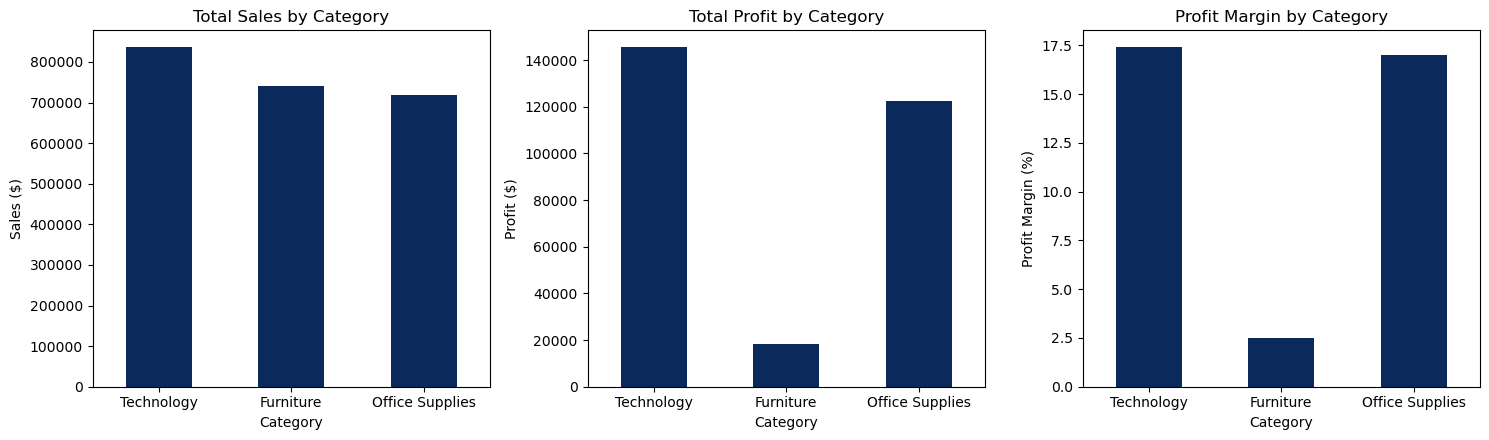

In [4]:
# ============================================
# SALES, PROFIT AND MARGIN BY CATEGORY
# ============================================

category_analysis = (
    df.groupby("Category")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Quantity=("Quantity", "sum")
      )
      .sort_values("Total_Sales", ascending=False)
)

category_analysis["Profit_Margin_%"] = (
    category_analysis["Total_Profit"] / category_analysis["Total_Sales"]
) * 100

display(category_analysis.round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

category_analysis["Total_Sales"].plot(kind="bar", ax=axes[0], color=NAVY)
axes[0].set_title("Total Sales by Category")
axes[0].set_ylabel("Sales ($)")

category_analysis["Total_Profit"].plot(kind="bar", ax=axes[1], color=NAVY)
axes[1].set_title("Total Profit by Category")
axes[1].set_ylabel("Profit ($)")

category_analysis["Profit_Margin_%"].plot(kind="bar", ax=axes[2], color=NAVY)
axes[2].set_title("Profit Margin by Category")
axes[2].set_ylabel("Profit Margin (%)")

for ax in axes:
    ax.set_xlabel("Category")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

**Insight:** **Technology** leads in both sales (**$836K**) and profit (**$145K**) with a strong **17.40% margin**. **Office Supplies** is similar at **17.02%**. **Furniture** has almost the same sales as Office Supplies ($741K) but earns only **$18K profit (2.49% margin)**, so it is the weak spot of the business.

## 3. Region Analysis

,Total_Sales,Total_Profit,Profit_Margin_%
Region,,,
West,725255.64,108329.81,14.94
East,678435.20,91506.31,13.49
Central,500782.85,39655.88,7.92
South,391721.90,46749.43,11.93


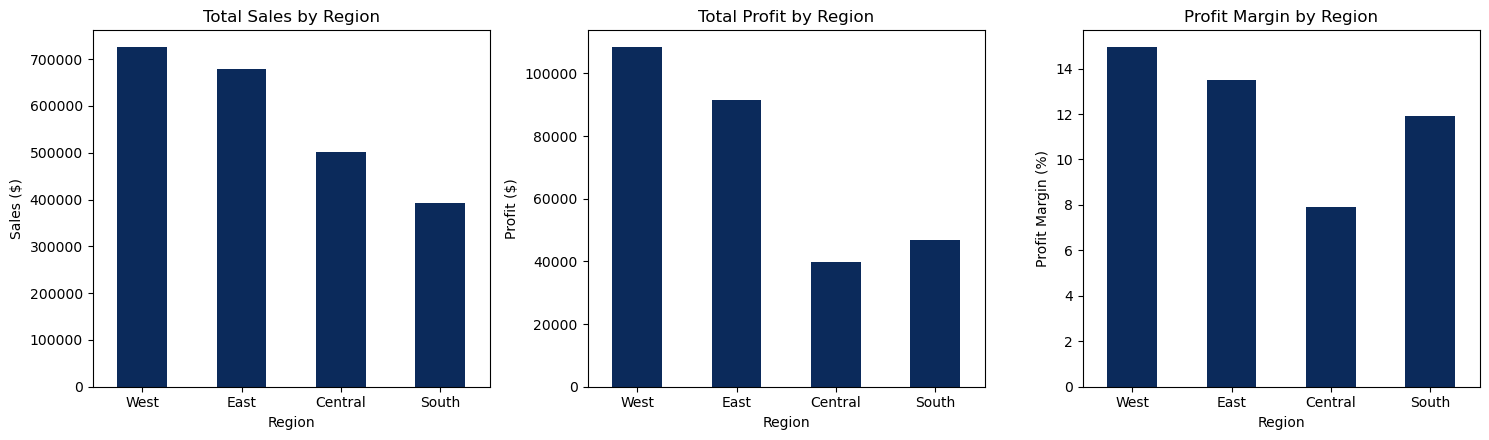

In [5]:
# ============================================
# SALES, PROFIT AND MARGIN BY REGION
# ============================================

region_analysis = (
    df.groupby("Region")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum")
      )
      .sort_values("Total_Sales", ascending=False)
)

region_analysis["Profit_Margin_%"] = (
    region_analysis["Total_Profit"] / region_analysis["Total_Sales"]
) * 100

display(region_analysis.round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

region_analysis["Total_Sales"].plot(kind="bar", ax=axes[0], color=NAVY)
axes[0].set_title("Total Sales by Region")
axes[0].set_ylabel("Sales ($)")

region_analysis["Total_Profit"].plot(kind="bar", ax=axes[1], color=NAVY)
axes[1].set_title("Total Profit by Region")
axes[1].set_ylabel("Profit ($)")

region_analysis["Profit_Margin_%"].plot(kind="bar", ax=axes[2], color=NAVY)
axes[2].set_title("Profit Margin by Region")
axes[2].set_ylabel("Profit Margin (%)")

for ax in axes:
    ax.set_xlabel("Region")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

**Insight:** **West** ($725K sales, $108K profit) and **East** ($678K sales, $92K profit) are the strongest regions. **Central** has the lowest margin of all regions: it sells **$501K but earns only $40K (7.9% margin)**, which is even less profit than South, which sells much less ($392K) but earns $47K (11.9% margin). Central is the region to investigate.

## 4. Segment Analysis

,Total_Sales,Total_Profit,Total_Quantity,Sales_Share_%,Profit_Margin_%
Segment,,,,,
Consumer,1160832.77,134007.44,19497,50.55,11.54
Corporate,706070.13,91954.98,11591,30.75,13.02
Home Office,429292.68,60279.00,6732,18.70,14.04


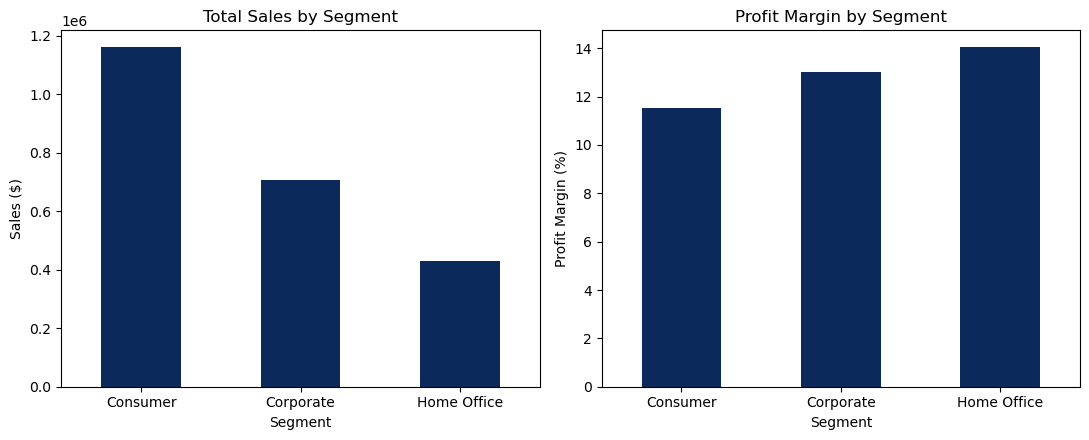

In [6]:
# ============================================
# SALES AND PROFIT BY SEGMENT
# ============================================

segment_analysis = (
    df.groupby("Segment")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Quantity=("Quantity", "sum")
      )
      .sort_values("Total_Sales", ascending=False)
)

segment_analysis["Sales_Share_%"] = (
    segment_analysis["Total_Sales"] / segment_analysis["Total_Sales"].sum()
) * 100

segment_analysis["Profit_Margin_%"] = (
    segment_analysis["Total_Profit"] / segment_analysis["Total_Sales"]
) * 100

display(segment_analysis.round(2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

segment_analysis["Total_Sales"].plot(kind="bar", ax=axes[0], color=NAVY)
axes[0].set_title("Total Sales by Segment")
axes[0].set_ylabel("Sales ($)")

segment_analysis["Profit_Margin_%"].plot(kind="bar", ax=axes[1], color=NAVY)
axes[1].set_title("Profit Margin by Segment")
axes[1].set_ylabel("Profit Margin (%)")

for ax in axes:
    ax.set_xlabel("Segment")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

**Insight:** **Consumer** is the largest segment with **50.55%** of total sales, followed by **Corporate (30.75%)** and **Home Office (18.70%)**. These shares match the donut chart in the Power BI dashboard. Compare the margin chart to see whether the biggest segment is also the most profitable.

## 5. Sub-Category Analysis

In [7]:
# ============================================
# SALES, PROFIT AND MARGIN BY SUB-CATEGORY
# ============================================

subcategory_analysis = (
    df.groupby("Sub-Category")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Quantity=("Quantity", "sum")
      )
      .sort_values("Total_Sales", ascending=False)
)

subcategory_analysis["Profit_Margin_%"] = (
    subcategory_analysis["Total_Profit"] / subcategory_analysis["Total_Sales"]
) * 100

display(subcategory_analysis.round(2))

,Total_Sales,Total_Profit,Total_Quantity,Profit_Margin_%
Sub-Category,,,,
Phones,330007.05,44515.73,3289,13.49
Chairs,327777.76,26567.13,2351,8.11
Storage,223843.61,21278.83,3158,9.51
Tables,206965.53,-17725.48,1241,-8.56
Binders,203409.17,30228.00,5971,14.86
Machines,189238.63,3384.76,440,1.79
Accessories,167380.32,41936.64,2976,25.05
Copiers,149528.03,55617.82,234,37.20
Bookcases,114880.00,-3472.56,868,-3.02


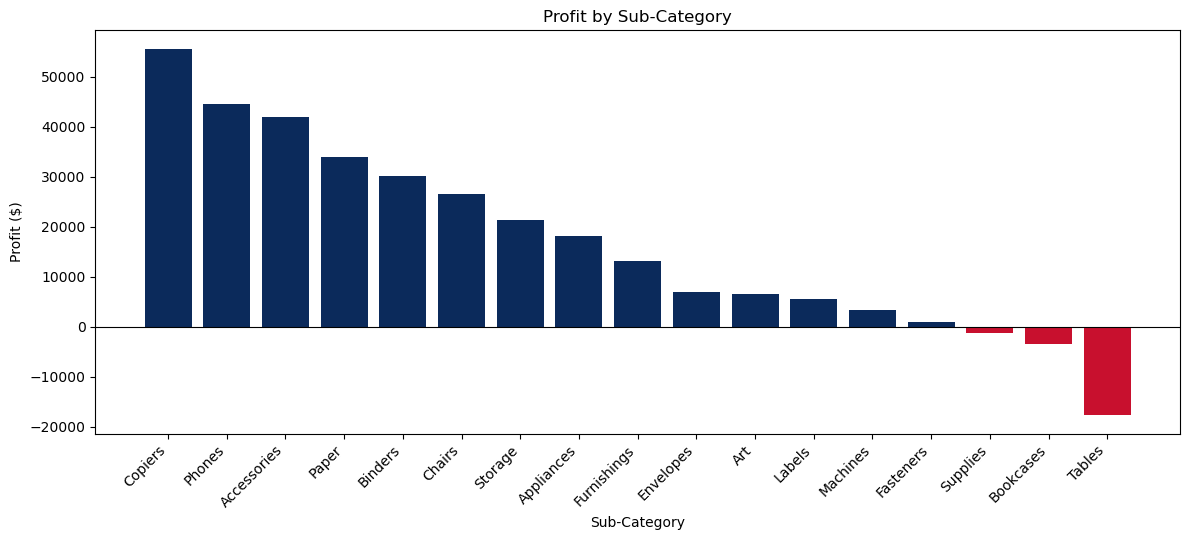

In [8]:
# ============================================
# PROFIT BY SUB-CATEGORY (LOSSES IN RED)
# ============================================

profit_by_sub = subcategory_analysis["Total_Profit"].sort_values(ascending=False)

plt.figure(figsize=(12, 5.5))
plt.bar(profit_by_sub.index, profit_by_sub.values, color=bar_colors(profit_by_sub.values))
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Profit by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Profit ($)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

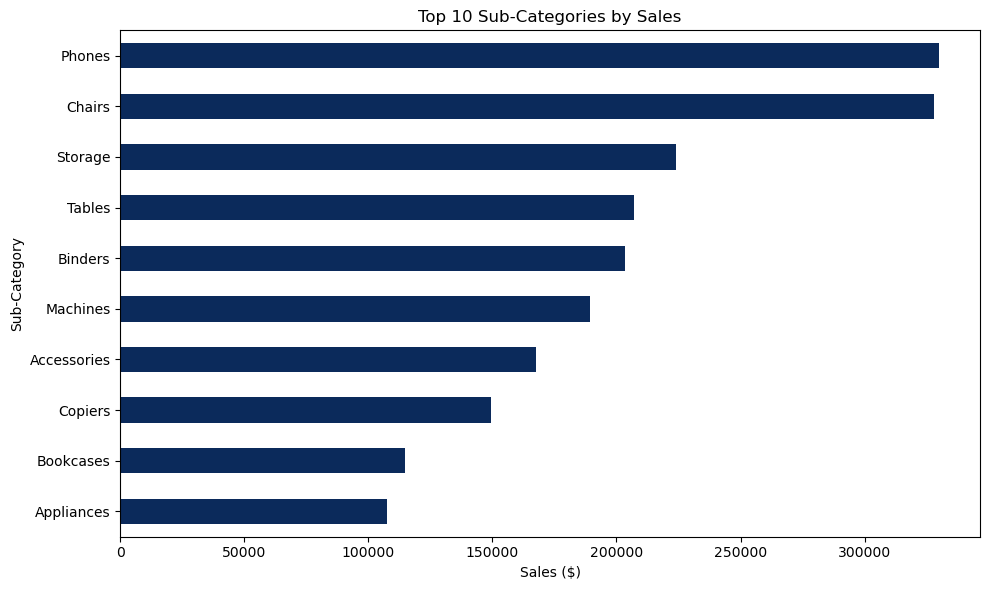

In [9]:
# ============================================
# TOP 10 SUB-CATEGORIES BY SALES
# ============================================

top_subcategories = subcategory_analysis["Total_Sales"].sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_subcategories.sort_values().plot(kind="barh", color=NAVY)
plt.title("Top 10 Sub-Categories by Sales")
plt.xlabel("Sales ($)")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()

In [10]:
# ============================================
# LOSS-MAKING SUB-CATEGORIES
# ============================================

loss_making_subcategories = (
    subcategory_analysis.loc[subcategory_analysis["Total_Profit"] < 0, ["Total_Sales", "Total_Profit", "Profit_Margin_%"]]
    .sort_values("Total_Profit")
)

print("Loss-Making Sub-Categories:")
display(loss_making_subcategories.round(2))

Loss-Making Sub-Categories:


,Total_Sales,Total_Profit,Profit_Margin_%
Sub-Category,,,
Tables,206965.53,-17725.48,-8.56
Bookcases,114880.00,-3472.56,-3.02
Supplies,46673.54,-1189.10,-2.55


**Insight:** **Copiers** earn the most profit (**$56K**), followed by Phones ($45K) and Accessories ($42K). High-volume items like Phones and Chairs earn much lower margins than small items like Paper (43%), Labels (44%) and Envelopes (42%).

Three sub-categories lose money: **Tables (-$17.7K, -8.56% margin)**, **Bookcases (-$3.5K)** and **Supplies (-$1.2K)**. Tables is the biggest loss and is the main reason Furniture's margin is only 2.49%.

## 6. Discount Analysis

In [11]:
# ============================================
# PROFIT BY EXACT DISCOUNT VALUE
# ============================================

discount_analysis = (
    df.groupby("Discount")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Average_Profit=("Profit", "mean")
      )
      .reset_index()
      .sort_values("Discount")
)

display(discount_analysis.round(2))

,Discount,Total_Sales,Total_Profit,Average_Profit
0,0.00,1087277.56,320844.41,67.02
1,0.10,54369.35,9029.18,96.06
2,0.15,27558.52,1418.99,27.29
3,0.20,764504.94,90306.61,24.72
4,0.30,102945.28,-10357.22,-45.83
5,0.32,14493.46,-2391.14,-88.56
6,0.40,116417.78,-23057.05,-111.93
7,0.45,5484.97,-2493.11,-226.65
8,0.50,58918.54,-20506.43,-310.70
9,0.60,6644.70,-5944.66,-43.08


,Total_Profit
Discount_Band,
0%,320844.41
1-20%,100754.78
21-40%,-35805.41
41%+,-99552.35


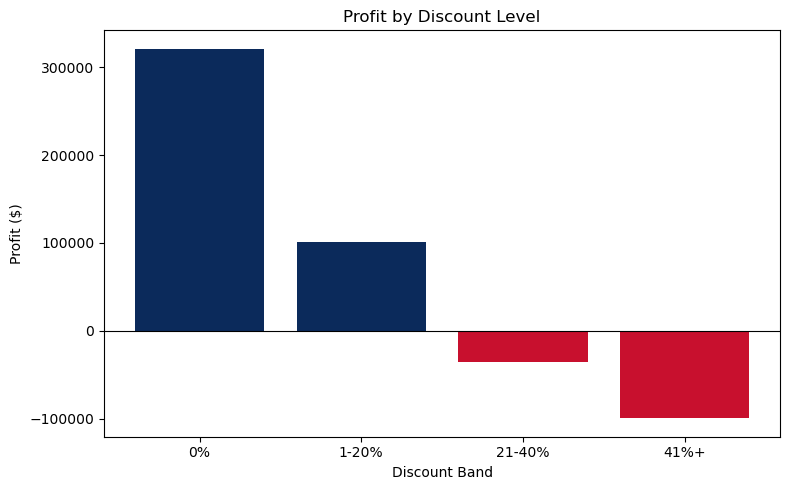

Profit from orders with discount above 20%: $-135,358
Profit from orders with no discount:        $320,844


In [14]:
# ============================================
# PROFIT BY DISCOUNT LEVEL (BANDS)
# ============================================

bins = [-0.001, 0, 0.2, 0.4, 1]
labels = ["0%", "1-20%", "21-40%", "41%+"]
df["Discount_Band"] = pd.cut(df["Discount"], bins=bins, labels=labels)

discount_band = df.groupby("Discount_Band", observed=True)["Profit"].sum()
display(discount_band.round(2).to_frame("Total_Profit"))

plt.figure(figsize=(8, 5))
plt.bar(discount_band.index.astype(str), discount_band.values, color=bar_colors(discount_band.values))
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Profit by Discount Level")
plt.xlabel("Discount Band")
plt.ylabel("Profit ($)")
plt.tight_layout()
plt.show()

high_discount = df[df["Discount"] > 0.2]
no_discount = df[df["Discount"] == 0]

print(f"Profit from orders with discount above 20%: ${high_discount['Profit'].sum():,.0f}")
print(f"Profit from orders with no discount:        ${no_discount['Profit'].sum():,.0f}")

**Insight:** Orders with **no discount** earned **$321K** and small discounts (1-20%) earned **$101K**. **Every discount above 20% loses money**: the 21-40% band lost $36K and the 41%+ band lost $100K, about **$135K** in total. This is the strongest finding of the analysis, because the loss from heavy discounting is almost half of the total profit ($286K).

## 7. State Analysis

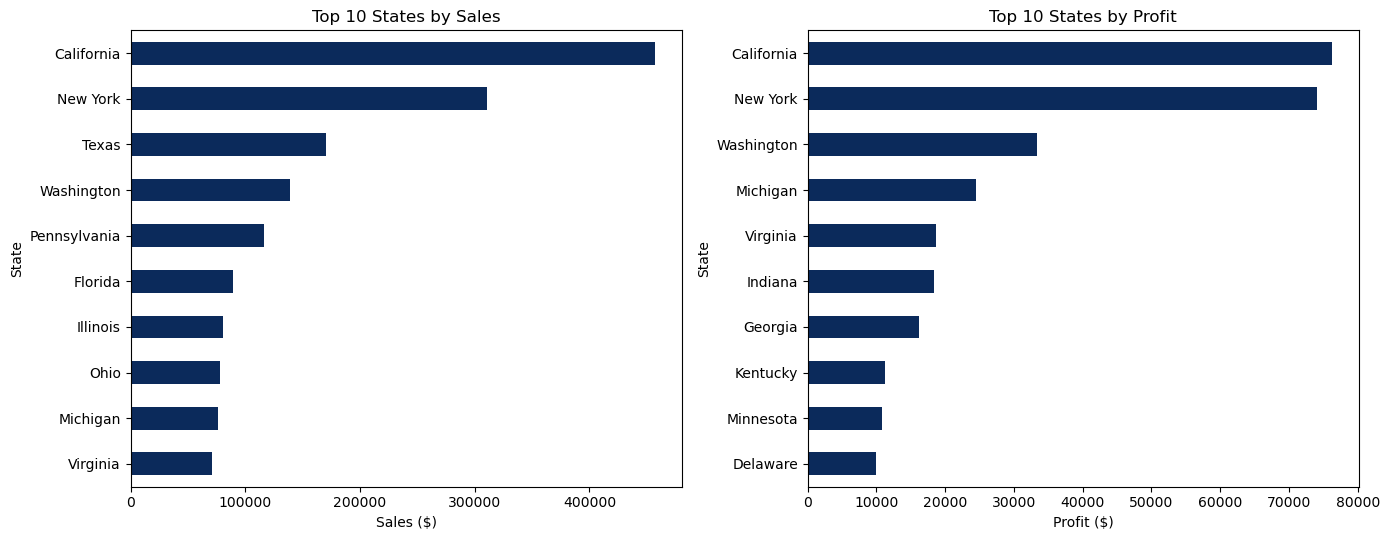

States with a total loss: 10


,Total_Profit
State,
Texas,-25750.98
Ohio,-16959.32
Pennsylvania,-15565.40
Illinois,-12601.65
North Carolina,-7490.91
Colorado,-6527.86
Tennessee,-5341.69
Arizona,-3427.92
Florida,-3399.30


In [ ]:
# ============================================
# TOP 10 STATES BY SALES AND PROFIT
# ============================================

state_analysis = (
    df.groupby("State")
      .agg(Total_Sales=("Sales", "sum"), Total_Profit=("Profit", "sum"))
)

top_states_sales = state_analysis["Total_Sales"].sort_values(ascending=False).head(10)
top_states_profit = state_analysis["Total_Profit"].sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

top_states_sales.sort_values().plot(kind="barh", ax=axes[0], color=NAVY)
axes[0].set_title("Top 10 States by Sales")
axes[0].set_xlabel("Sales ($)")

top_states_profit.sort_values().plot(kind="barh", ax=axes[1], color=NAVY)
axes[1].set_title("Top 10 States by Profit")
axes[1].set_xlabel("Profit ($)")

plt.tight_layout()
plt.show()

loss_states = state_analysis.loc[state_analysis["Total_Profit"] < 0, "Total_Profit"].sort_values()
print(f"States with a total loss: {len(loss_states)}")
print(loss_states.round(2).to_string())

**Insight:** **California** and **New York** lead in both sales and profit, followed by **Washington** in profit. However, **10 states lose money overall**, with a combined loss of about **$98K**. **Texas** is the largest loss-making state (-$25.8K) even though it is third in sales (about $170K), followed by **Ohio (-$17.0K)**, **Pennsylvania (-$15.6K)** and **Illinois (-$12.6K)**. High sales do not guarantee high profit, so these states should be reviewed for discounting and pricing.

## 8. Final EDA Summary

In [13]:
# ============================================
# FINAL EDA SUMMARY
# ============================================

print("============================================")
print("SUPERSTORE EDA SUMMARY")
print("============================================")

print(f"Total Sales: ${df['Sales'].sum():,.2f}")
print(f"Total Profit: ${df['Profit'].sum():,.2f}")
print(f"Total Quantity: {df['Quantity'].sum():,}")

print("\nHighest Sales Category:      ", df.groupby("Category")["Sales"].sum().idxmax())
print("Highest Profit Category:     ", df.groupby("Category")["Profit"].sum().idxmax())
print("Lowest Margin Category:      ", category_analysis["Profit_Margin_%"].idxmin())
print("Highest Sales Region:        ", df.groupby("Region")["Sales"].sum().idxmax())
print("Highest Profit Region:       ", df.groupby("Region")["Profit"].sum().idxmax())
print("Largest Segment (Sales):     ", df.groupby("Segment")["Sales"].sum().idxmax())
print("Most Profitable Sub-Category:", df.groupby("Sub-Category")["Profit"].sum().idxmax())
print("Least Profitable Sub-Category:", df.groupby("Sub-Category")["Profit"].sum().idxmin())

SUPERSTORE EDA SUMMARY
Total Sales: $2,296,195.59
Total Profit: $286,241.42
Total Quantity: 37,820

Highest Sales Category:       Technology
Highest Profit Category:      Technology
Lowest Margin Category:       Furniture
Highest Sales Region:         West
Highest Profit Region:        West
Largest Segment (Sales):      Consumer
Most Profitable Sub-Category: Copiers
Least Profitable Sub-Category: Tables


### Key Findings
1. **Technology** is the best category: highest sales ($836K) and profit ($145K) at a 17.40% margin.
2. **Furniture** has a weak margin of only **2.49%**, mainly because of **Tables** (-$17.7K).
3. **Discounts above 20% always lose money** (about $135K in total), while orders with no discount earned $321K.
4. **West** and **East** lead in sales and profit, while **Central** has a low margin (7.9%).
5. **Consumer** is the largest segment (50.55% of sales).

### Recommendations
- Review the discount policy and cap discounts at about 20%.
- Review pricing and costs for **Tables**, **Bookcases** and **Supplies**.
- Investigate why **Central** converts sales into profit less efficiently than other regions.
- Protect and grow **Technology** and **Office Supplies**, which have the best margins.